<a href="https://colab.research.google.com/github/uniitee/Celebal_Excellence_Intern_2026/blob/main/Week3_CountryDataset_UmaGhldiyal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LOAD AND INSPECT DATA

In [1]:
!pip install opendatasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: umagld
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data


100%|██████████| 5.21k/5.21k [00:00<00:00, 8.02MB/s]

In [3]:
df = pd.read_csv(
    "/content/unsupervised-learning-on-country-data/Country-data.csv"
)

In [4]:
df_desc = pd.read_csv(
    "/content/unsupervised-learning-on-country-data/data-dictionary.csv"
)
df_desc.head(10)

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [5]:
# Basic Inspection of the Data
print(
    "SHAPE:", df.shape,
    "\n\nINFO:\n", df.info(),
    "\n\nDESCRIBE:\n", df.describe(),
    "\n\nNULL VALUES:\n", df.isnull().sum()
    )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
SHAPE: (167, 10) 

INFO:
 None 

DESCRIBE:
        child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min     

1. income
> - Mean = 17,144
> - Median = 9,960
> - q3 = 22,208
> - Max = 125,000

1. gdpp
> - Mean = 12,964
> - Median = 4,660
> - Max = 105,000

3. child_mort
> - Mean = 38.27
> - Median = 19.3
> - Q3 = 62.1
> - Max = 208

- The Dataset has the mean > median (50%), i.e. right-skewed distributions
- upwards gdp and income -> few rich countries
- (large gap ffrom q3 -> outliers (?) )
- some countries -> very high child mortality



In [6]:
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


# EXPLORATORY DATA ANALYSIS

<function matplotlib.pyplot.show(close=None, block=None)>

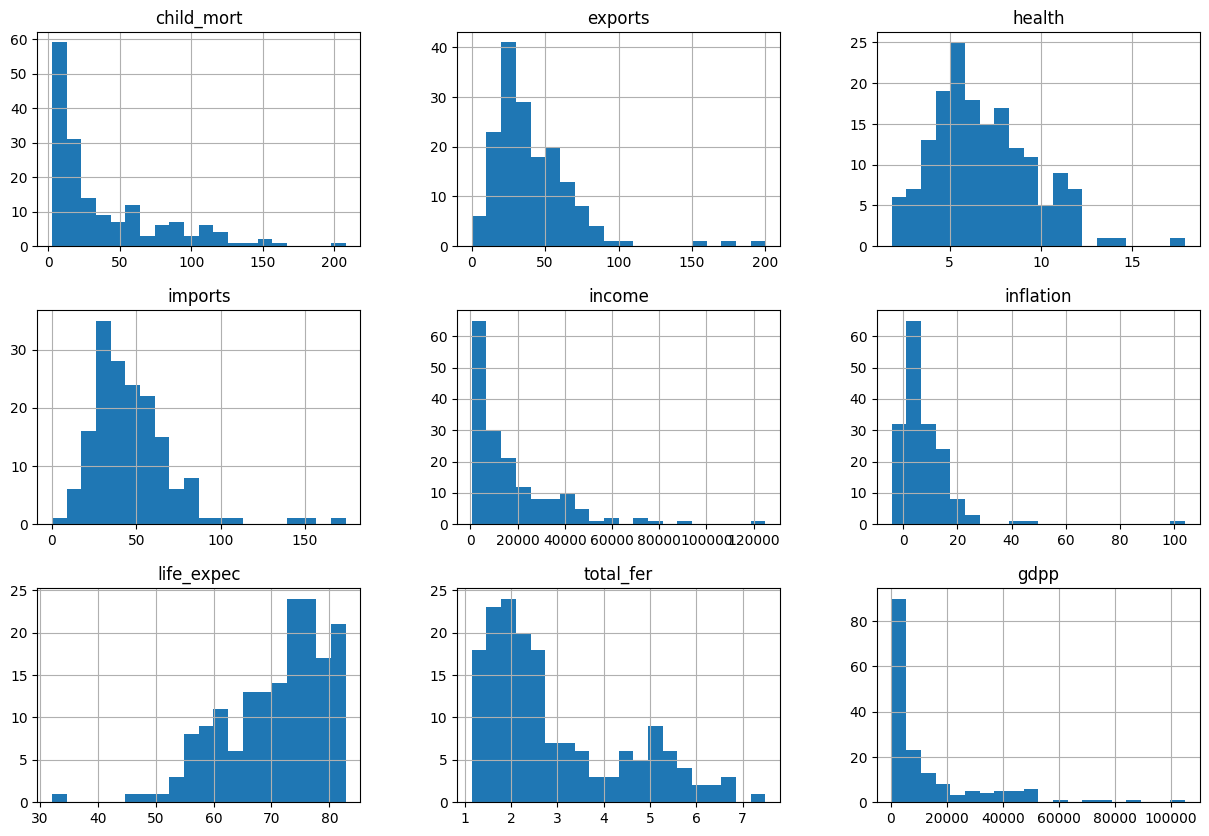

In [7]:
# Histograms for Numeric Features
df.hist(figsize=(15,10), bins=20)
plt.show

- Suspected skew was correct
> - icome, gdpp, child_mort, inflation -> strong right skew
> - only a few countries with extremely high vals

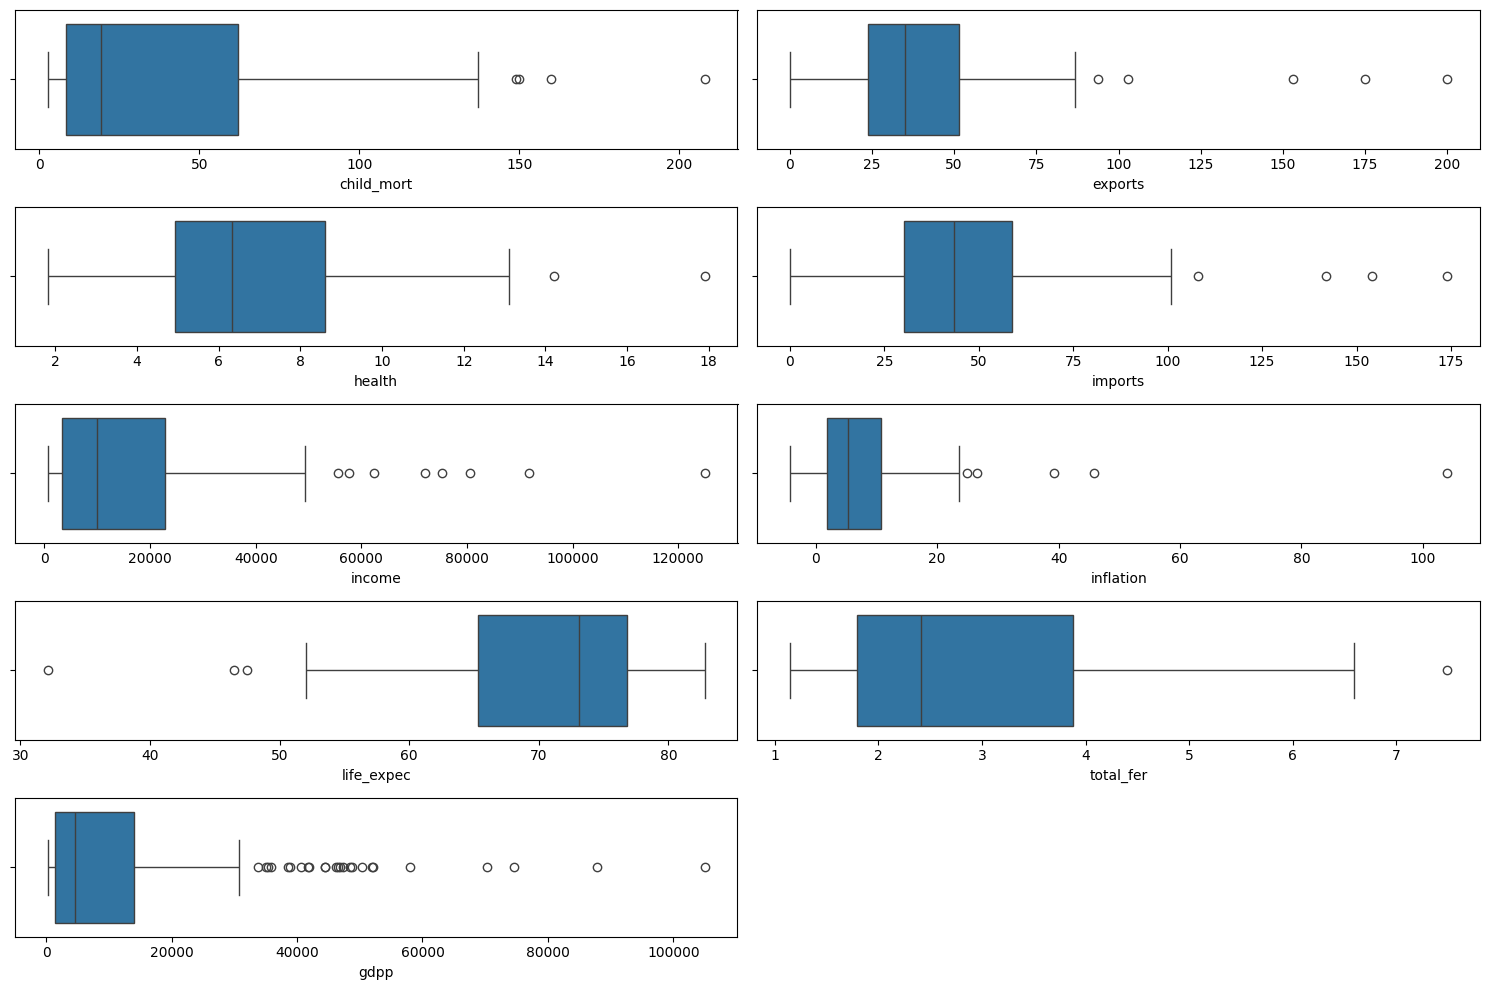

In [8]:
# Boxplot for Outliers
cols = df.columns[1:]
fig, axes = plt.subplots(5, 2, sharex=False, figsize=(15,10))
axes = axes.flatten()

for i,col in enumerate(cols):
  sns.boxplot(x=df[col], ax=axes[i])

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- significant outliers in (income, gdpp, inflation, exports, imports,chld_mort)

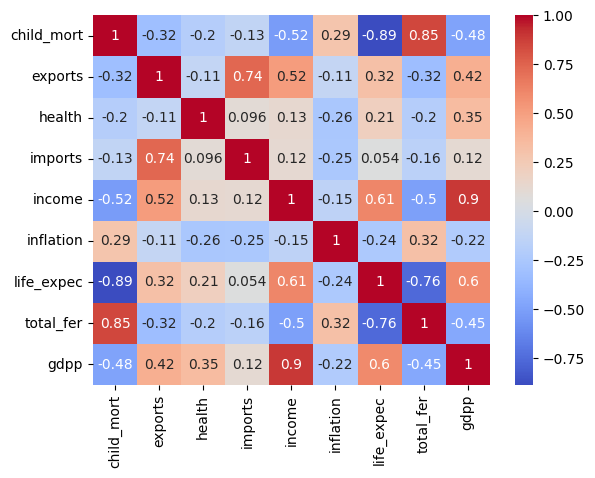

In [9]:
# Corelation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

Strong Positive Corellation
- income, gdpp (potential multicollinearity)
- exports, imports
- income, life_expec

Strong Negative Corellation
- life_expec, child_mort
- life_expec, total_fertility
- income, child_mort

Wealthier country -> Higher life expectancy

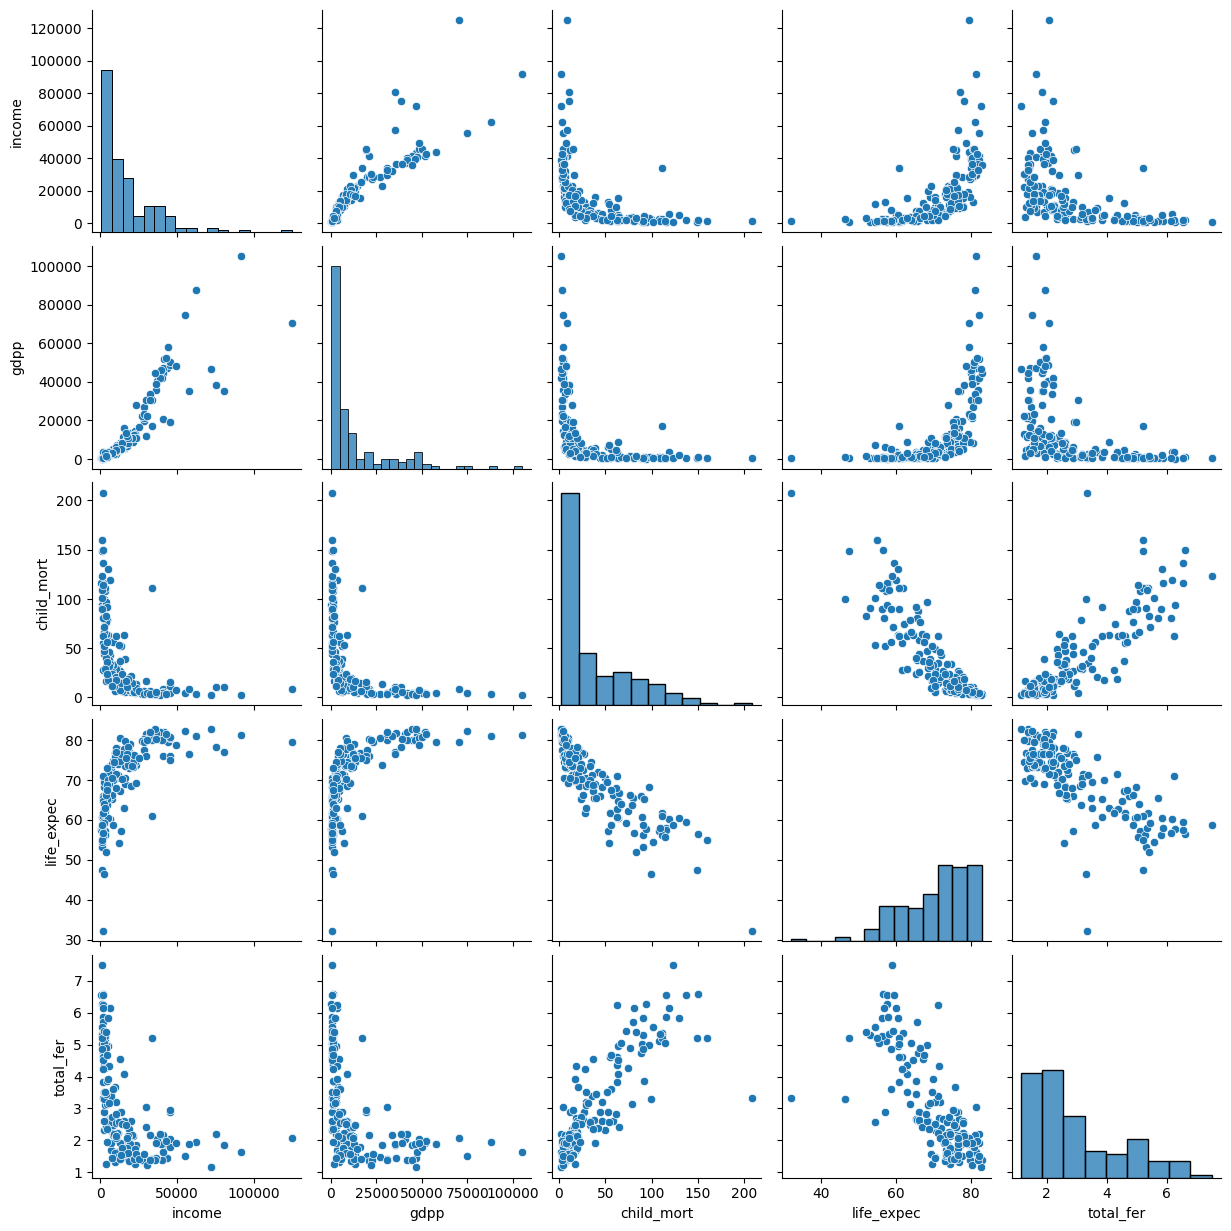

In [10]:
# Pairplots
cols=[
    'income',
    'gdpp',
    'child_mort',
    'life_expec',
    'total_fer'
]
sns.pairplot(df[cols])

Natural groups visible:
- High income + high life expectancy + low fertility
- Low income + high mortality + high fertility

Nonlinear Relationship Between
- income, lif_expec
- child_mort, life_expec
- child_mort, total_fert
- income, child_mort

# FEATURE ENGINEERING

In [11]:
# Handeling Outliers
skewed = ['income', 'gdpp', 'child_mort', 'inflation', 'total_fer']
for col in skewed:
  df[col + '_log'] = np.log1p(df[col])
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,income_log,gdpp_log,child_mort_log,inflation_log,total_fer_log
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,7.384610,6.317165,4.513055,2.345645,1.919859
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,9.203416,8.316545,2.867899,1.702928,0.974560
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,9.465060,8.403128,3.342862,2.839078,1.358409
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,8.682877,8.169336,4.787492,3.152736,1.968510
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,9.857496,9.409273,2.424803,0.891998,1.141033


In [12]:
# feature extraction
df['health_income_ratio'] = df['health'] / (df['income'] + 1)
df['trade_balance'] = df['exports'] - df['imports']
df['development_index'] = (df['life_expec'] / df['life_expec'].max()) - \
                           (df['child_mort'] / df['child_mort'].max())
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,income_log,gdpp_log,child_mort_log,inflation_log,total_fer_log,health_income_ratio,trade_balance,development_index
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,7.384610,6.317165,4.513055,2.345645,1.919859,0.004705,-34.9,0.245090
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,9.203416,8.316545,2.867899,1.702928,0.974560,0.000660,-20.6,0.841690
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,9.465060,8.403128,3.342862,2.839078,1.358409,0.000323,7.0,0.792663
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,8.682877,8.169336,4.787492,3.152736,1.968510,0.000483,19.4,0.153730
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,9.857496,9.409273,2.424803,0.891998,1.141033,0.000316,-13.4,0.878017


# CLUSTERING

In [13]:
cluster_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'health', 'inflation']
X_cluster = df[cluster_features].copy()

# Scaling All Data
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)


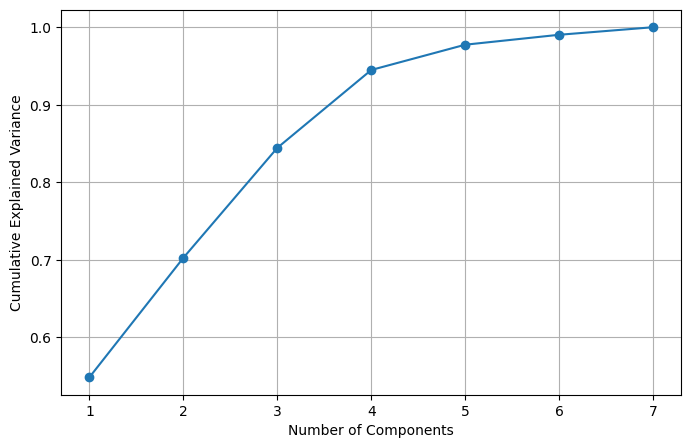

In [14]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(
    range(1,len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [15]:
# PCA (choosing 4 components -> 94%ish)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# K-Means
inertias, silhouettes = [], []
K_range = range(2, 10)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_pca)
  inertias.append(kmeans.inertia_)
  silhouettes.append(silhouette_score(X_pca, labels))

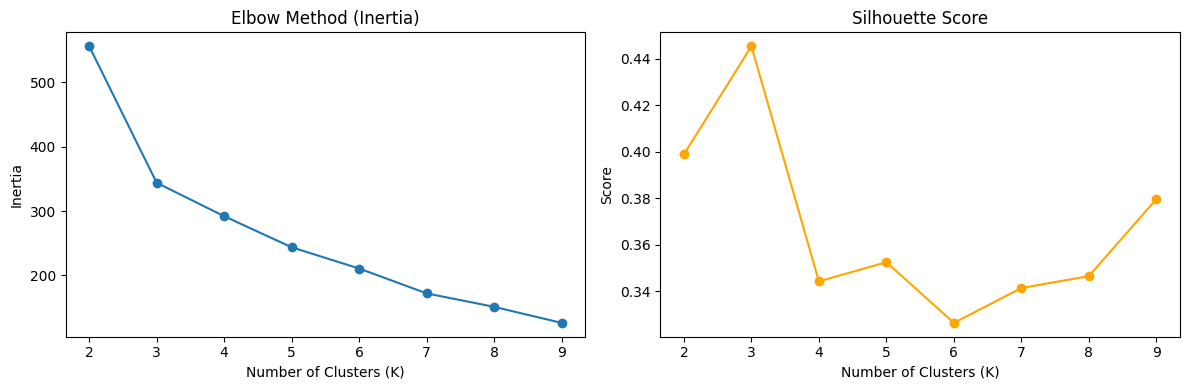

In [16]:
# Elbow Method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, marker='o')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, silhouettes, marker='o', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

In [17]:
# Final K-Means (going with k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_pca)
print(df.groupby('kmeans_cluster')[cluster_features].mean())

                child_mort        income          gdpp  life_expec  total_fer  \
kmeans_cluster                                                                  
0                 4.903125  47475.000000  45331.250000   80.484375   1.774062   
1                21.113793  13297.586207   7158.298851   73.147126   2.251954   
2                91.610417   3897.354167   1909.208333   59.239583   4.992083   

                  health  inflation  
kmeans_cluster                       
0               9.015937   2.703438  
1               6.217241   7.371506  
2               6.433542  11.911146  


In [18]:
# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=4)
df['dbscan_cluster'] = dbscan.fit_predict(X_pca)

print("DBSCAN Cluster Distribution:")
print(df['dbscan_cluster'].value_counts().sort_index())

# OutLiers
outliers = df[df['dbscan_cluster'] == -1][['country', 'income', 'gdpp', 'child_mort']]
print("\nDBSCAN Outliers (noise points):")
print(outliers)

DBSCAN Cluster Distribution:
dbscan_cluster
-1     22
 0    145
Name: count, dtype: int64

DBSCAN Outliers (noise points):
                   country  income    gdpp  child_mort
3                   Angola    5900    3530       119.0
11                 Bahrain   41100   20700         8.6
23                  Brunei   80600   35300        10.5
49       Equatorial Guinea   33700   17100       111.0
66                   Haiti    1500     662       208.0
81                Kiribati    1730    1490        62.7
82                  Kuwait   75200   38500        10.8
88                 Liberia     700     327        89.3
91              Luxembourg   91700  105000         2.8
101  Micronesia, Fed. Sts.    3340    2860        40.0
103               Mongolia    7710    2650        26.1
113                Nigeria    5150    2330       130.0
114                 Norway   62300   87800         3.2
115                   Oman   45300   19300        11.7
123                  Qatar  125000   70300         9

Text(0.5, 1.0, 'K-Means Clusters in PCA Space')

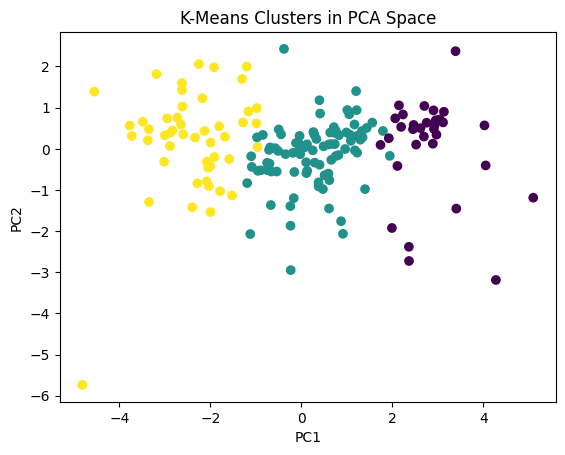

In [19]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['kmeans_cluster'], cmap='viridis')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('K-Means Clusters in PCA Space')

In [20]:
# Creating Target from Clusters
cluster_map = {
    0: 'Developed',
    1: 'Developing',
    2: 'Underdeveloped'
}
df['development_stage'] = df['kmeans_cluster'].map(cluster_map)

In [21]:
print(df['development_stage'].value_counts())

development_stage
Developing        87
Underdeveloped    48
Developed         32
Name: count, dtype: int64


In [22]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,gdpp_log,child_mort_log,inflation_log,total_fer_log,health_income_ratio,trade_balance,development_index,kmeans_cluster,dbscan_cluster,development_stage
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,6.317165,4.513055,2.345645,1.919859,0.004705,-34.9,0.245090,2,0,Underdeveloped
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,8.316545,2.867899,1.702928,0.974560,0.000660,-20.6,0.841690,1,0,Developing
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,8.403128,3.342862,2.839078,1.358409,0.000323,7.0,0.792663,1,0,Developing
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,8.169336,4.787492,3.152736,1.968510,0.000483,19.4,0.153730,2,-1,Underdeveloped
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,9.409273,2.424803,0.891998,1.141033,0.000316,-13.4,0.878017,1,0,Developing


# CLASSIFICATION

In [23]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'income_log',
       'gdpp_log', 'child_mort_log', 'inflation_log', 'total_fer_log',
       'health_income_ratio', 'trade_balance', 'development_index',
       'kmeans_cluster', 'dbscan_cluster', 'development_stage'],
      dtype='object')

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
features = [
    'inflation_log',
    'total_fer_log',
    'health',
    'exports',
    'imports',
    'health_income_ratio',
    'trade_balance',
]


X = df[features].copy()
y = df['development_stage']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
# Scaling the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Encoding Labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [28]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

In [29]:
print(df.groupby('kmeans_cluster')[['child_mort', 'income',
                                     'life_expec', 'gdpp']].mean())

                child_mort        income  life_expec          gdpp
kmeans_cluster                                                    
0                 4.903125  47475.000000   80.484375  45331.250000
1                21.113793  13297.586207   73.147126   7158.298851
2                91.610417   3897.354167   59.239583   1909.208333


In [30]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train_encoded)

# XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1_weighted', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train_encoded)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='f1_weighted')

In [31]:
# Evaluate
for name, model in [('Random Forest', rf_grid), ('XGBoost', xgb_grid)]:
    preds = model.predict(X_test_scaled)
    print(f"\n{name}:\n", classification_report(y_test_encoded, preds,
                                                  target_names=le.classes_))


Random Forest:
                 precision    recall  f1-score   support

     Developed       1.00      0.75      0.86         8
    Developing       0.86      0.95      0.90        19
Underdeveloped       0.86      0.86      0.86         7

      accuracy                           0.88        34
     macro avg       0.90      0.85      0.87        34
  weighted avg       0.89      0.88      0.88        34


XGBoost:
                 precision    recall  f1-score   support

     Developed       1.00      0.75      0.86         8
    Developing       0.85      0.89      0.87        19
Underdeveloped       0.75      0.86      0.80         7

      accuracy                           0.85        34
     macro avg       0.87      0.83      0.84        34
  weighted avg       0.86      0.85      0.85        34



- Both are performing similarly with neglegible differnce
- Random Forest Performs Slightly Better

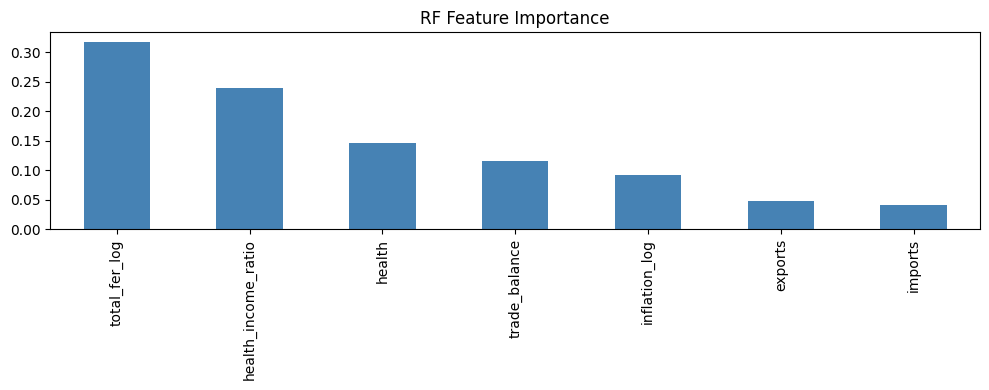

In [32]:
# Feature Importance
feat_imp = pd.Series(
    rf_grid.best_estimator_.feature_importances_,
    index=features
).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10, 4),
              title='RF Feature Importance',
              color='steelblue')
plt.tight_layout()
plt.show()

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [34]:
# Cross Validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

for name, model in [('Random Forest', rf_grid.best_estimator_), ('XGBoost', xgb_grid.best_estimator_)]:
    scores = cross_validate(
        model,
        X, y_encoded,
        cv=cv,
        scoring=['accuracy', 'f1_weighted']
    )
    print(f"\n{name}")
    print(f"  Accuracy: {scores['test_accuracy'].mean():.3f} "
          f"± {scores['test_accuracy'].std():.3f}")
    print(f"  F1:       {scores['test_f1_weighted'].mean():.3f} "
          f"± {scores['test_f1_weighted'].std():.3f}")


Random Forest
  Accuracy: 0.874 ± 0.034
  F1:       0.875 ± 0.034

XGBoost
  Accuracy: 0.880 ± 0.038
  F1:       0.881 ± 0.038


- This flips the earlier conclusion
- Since CV is more reliable than a single split -> XG Boost wins

In [35]:
# Final Model
print(f"Accuracy difference: {0.880 - 0.874:.3f}")
print(f"F1 difference:       {0.881 - 0.875:.3f}")

Accuracy difference: 0.006
F1 difference:       0.006


- since the differnce is neglegible
- Random Forest is being opted as final (due to interpretability)

# CLUSTER PROFILING

In [36]:
# Cluster profiling
profile = df.groupby('development_stage').agg({
    'child_mort': 'mean',
    'income':     'mean',
    'life_expec': 'mean',
    'gdpp':       'mean',
    'inflation':  'mean',
    'total_fer':  'mean'
}).round(2)

print(profile)

                   child_mort    income  life_expec      gdpp  inflation  \
development_stage                                                          
Developed                4.90  47475.00       80.48  45331.25       2.70   
Developing              21.11  13297.59       73.15   7158.30       7.37   
Underdeveloped          91.61   3897.35       59.24   1909.21      11.91   

                   total_fer  
development_stage             
Developed               1.77  
Developing              2.25  
Underdeveloped          4.99  


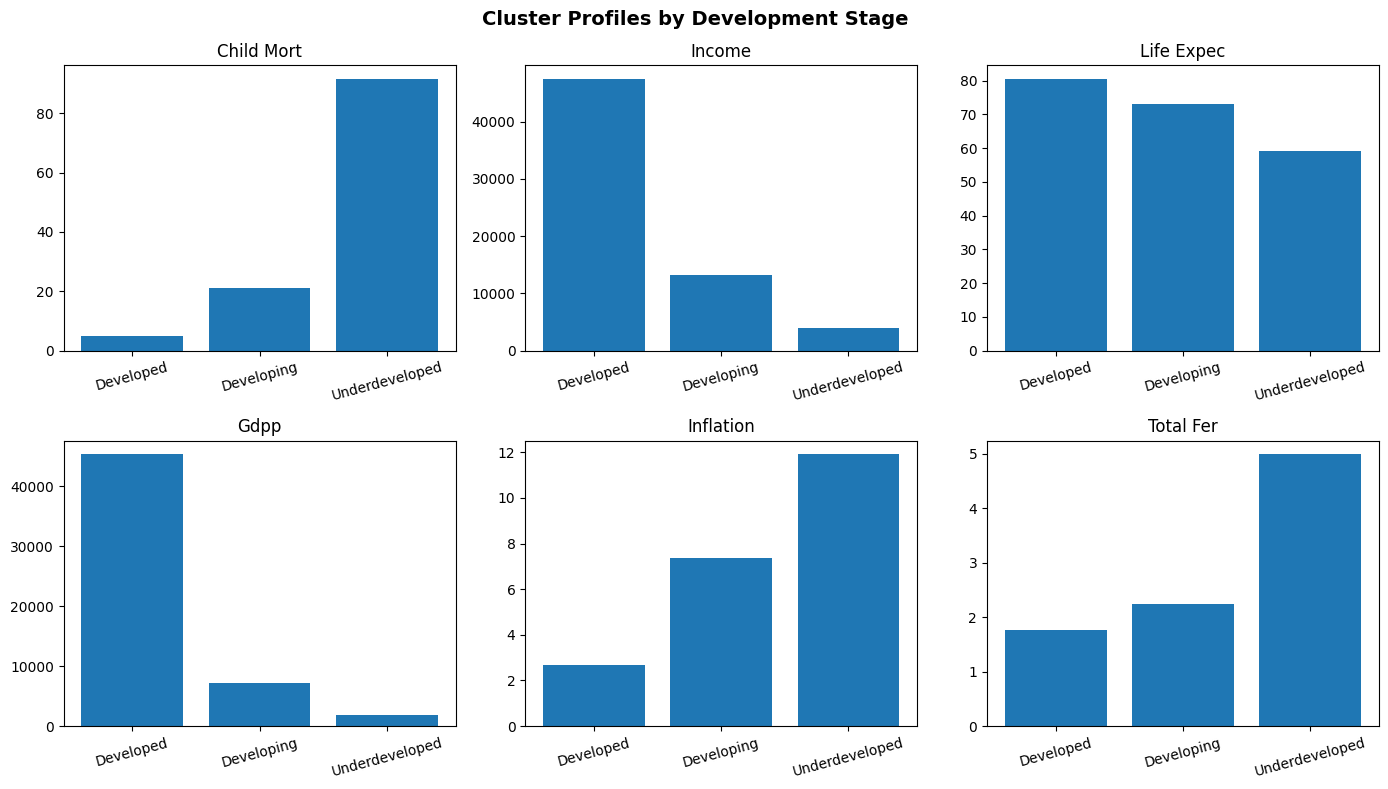

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
metrics = ['child_mort', 'income', 'life_expec',
           'gdpp', 'inflation', 'total_fer']
stages  = ['Developed', 'Developing', 'Underdeveloped']

for i, metric in enumerate(metrics):
    values = [profile.loc[s, metric] for s in stages]
    axes[i].bar(stages, values)
    axes[i].set_title(metric.replace('_', ' ').title())
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Cluster Profiles by Development Stage',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

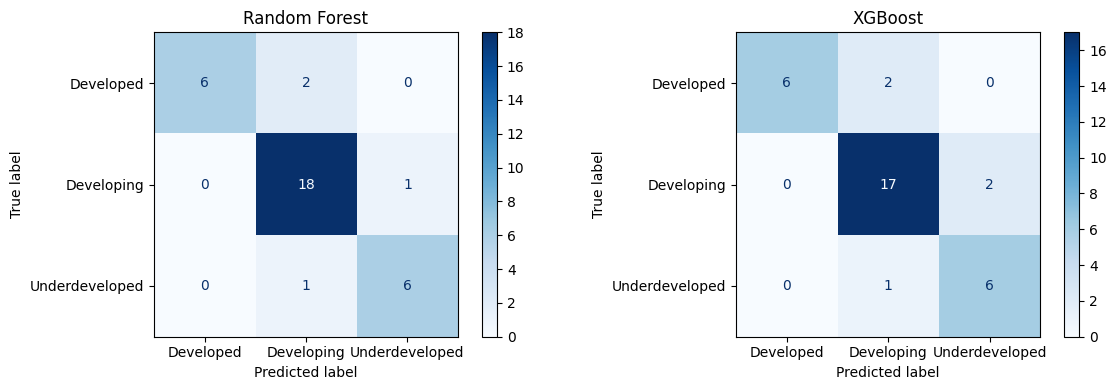

In [39]:
# Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, model, name in [(ax1, rf_grid, 'Random Forest'),
                         (ax2, xgb_grid, 'XGBoost')]:
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_scaled, y_test_encoded,
        display_labels=le.classes_,
        cmap='Blues', ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

# KEY FINDINGS

CLUSTERING (K-Means, K=3):
  - Developed (32 countries)
   > - Low child mortality (4.9)
   > - High income ($47k)
   > - Long life (80yrs)

  - Developing (87 countries)
  > - Middle ground across all metrics

  - Underdeveloped (48 countries)
  > - High child mortality (91.6)
  > - Low income ($3.9k)
  > - High fertility (5.0)

CLASSIFICATION
- (Random Forest — Final Model):
  > - Accuracy:  88% (test) | 87.4% +- 3.4% (cross-validated)

ACTIONABLE INSIGHTS:
  1. Fertility rate is the strongest indirect predictor of development stage
  2. Health spending relative to income distinguishes Developed from Developing nations
  3. Trade balance alone is insufficient — needs combination with health and fertility indicators